Скачайте датасет Fashion MNIST, посмотрите на картинки, отделите валидационную выборку и обучите одну полносвязную архитектуру. Выведите summary модели, посмотрите на графики обучения, сделайте выводы.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torchvision.transforms as T

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
train_full = datasets.FashionMNIST(root="./data", train=True, download=True, transform=T.ToTensor())
test_set   = datasets.FashionMNIST(root="./data", train=False, download=True, transform=T.ToTensor())


100%|██████████| 26.4M/26.4M [00:00<00:00, 123MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.85MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 61.9MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 30.1MB/s]


In [ ]:
train_full.data

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

In [ ]:
test_set.data.shape

torch.Size([10000, 28, 28])

In [ ]:
train_full.data.max()

tensor(255, dtype=torch.uint8)

In [4]:
mean = (train_full.data / 255).mean()
mean

tensor(0.2860)

In [5]:

std = (train_full.data / 255).std()
std

tensor(0.3530)

In [6]:
normalize = T.Normalize(mean=mean, std=std)
transform = T.Compose([
    T.ToTensor(),
    normalize
])
train_ds = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_ds = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

In [7]:
train_size = 50000
val_size = len(train_ds) - train_size
train_set, val_set = random_split(train_ds, [train_size, val_size], generator=torch.Generator())

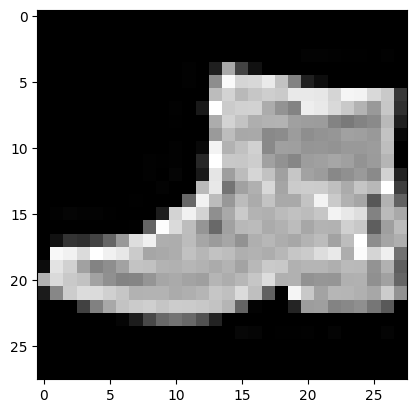

In [ ]:
img, label = train_set[0]        # img: torch.Tensor [1, 28, 28]
plt.imshow(img.squeeze(), cmap='grey')
plt.show()


In [8]:
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
valid_loader = DataLoader(val_set, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [9]:
from torch import nn

class FirstModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )
  def forward(self, x):
    return self.net(x)

In [10]:
loss = nn.CrossEntropyLoss()

In [11]:
from torch.optim import Adam

model = FirstModel().to(device)

optimizer = Adam(model.parameters(), lr=1e-3)

In [12]:
from tqdm import tqdm


def train(model: nn.Module, data_loader: DataLoader, optimizer, loss_fn, device: torch.device):
    model.train()

    total_loss = 0
    total_correct = 0

    for x, y in tqdm(data_loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        output = model(x)

        loss = loss_fn(output, y)

        loss.backward()

        total_loss += loss.item()

        total_correct += (output.argmax(dim=1) == y).sum().item()

        optimizer.step()

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)

In [13]:
@torch.inference_mode()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fn, device: torch.device):
    model.eval()

    total_loss = 0
    total_correct = 0

    for x, y in tqdm(data_loader):
        x, y = x.to(device), y.to(device)

        output = model(x)

        loss = loss_fn(output, y)

        total_loss += loss.item()

        total_correct += (output.argmax(dim=1) == y).sum().item()

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)


In [14]:
sns.set(style='darkgrid')


def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    train_accuracy: list[float],
    valid_accuracy: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()

    plt.show()

    plt.figure(figsize=(16, 8))

    plt.title(title + ' accuracy')

    plt.plot(train_accuracy, label='Train accuracy')
    plt.plot(valid_accuracy, label='Valid accuracy')
    plt.legend()

    plt.show()

In [15]:
from IPython.display import clear_output


def fit(model, train_loader, valid_loader, optimizer, loss_fn, device, num_epochs, title):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model, train_loader, optimizer, loss_fn, device)
        valid_loss, valid_accuracy = evaluate(model, valid_loader, loss_fn, device)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            title
        )

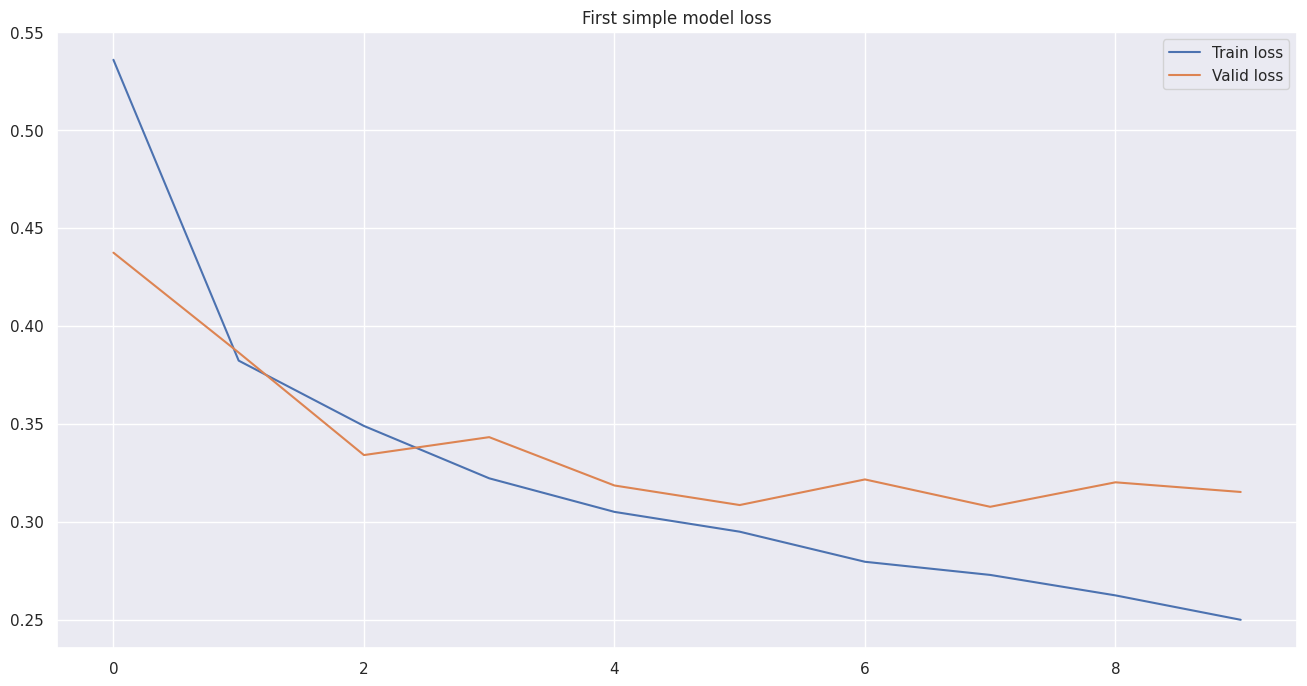

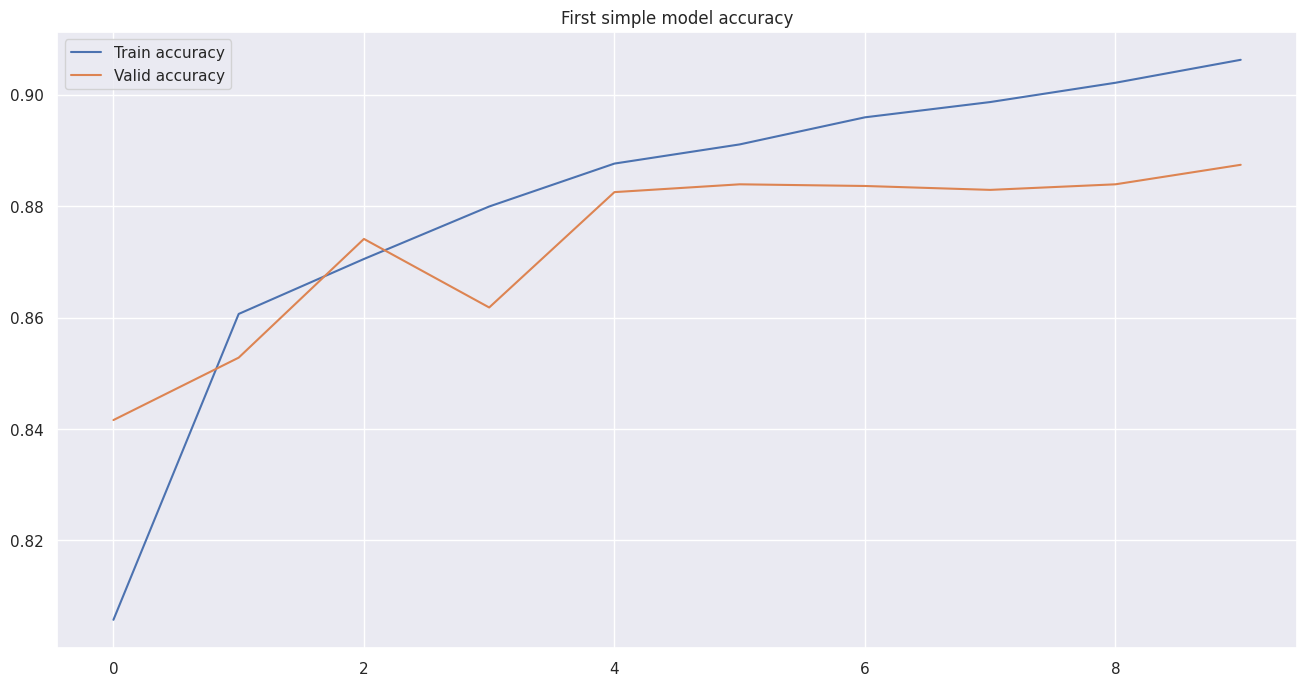

In [ ]:
model.to(device)
fit(model, train_loader, valid_loader, optimizer, loss, device, 10, 'First simple model')

In [21]:
pip install torchinfo


In [ ]:
from torchinfo import summary

summary(model, input_size=(1, 1, 28, 28))


Layer (type:depth-idx)                   Output Shape              Param #
FirstModel                               [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Flatten: 2-1                      [1, 784]                  --
│    └─Linear: 2-2                       [1, 512]                  401,920
│    └─ReLU: 2-3                         [1, 512]                  --
│    └─Dropout: 2-4                      [1, 512]                  --
│    └─Linear: 2-5                       [1, 256]                  131,328
│    └─ReLU: 2-6                         [1, 256]                  --
│    └─Dropout: 2-7                      [1, 256]                  --
│    └─Linear: 2-8                       [1, 128]                  32,896
│    └─ReLU: 2-9                         [1, 128]                  --
│    └─Linear: 2-10                      [1, 10]                   1,290
Total params: 567,434
Trainable params: 567,434
Non-trainable params

Модель показывает средние значения точности >88%, но имеет избыточное количество параметров для линейной модели, склонна к переобучению.

Добавьте в архитектуру свёртки. Выведите summary модели, посмотрите на графики обучения, сделайте выводы.

In [23]:
from torch import nn

class SecondModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.net = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1), #16x28x28
        nn.ReLU(),

        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1), #32x28x28
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), #64x14х14
        nn.ReLU(),
        nn.MaxPool2d(2), #64X7X17

        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2), #128x3x3

        nn.Flatten(),

        nn.Linear(in_features=1152, out_features=512),
        nn.ReLU(),
        nn.Linear(in_features=512, out_features=128),
        nn.ReLU(),
        nn.Linear(128, 10)
    )
  def forward(self, x):
    if x.ndim != 4:
        raise ValueError(f"Wrong input shape {x.shape}, expected (batch, 1, 28, 28)")
    return self.net(x)

In [24]:
from torch.optim import Adam

model2 = SecondModel().to(device)

optimizer = Adam(model2.parameters(), lr=1e-3)

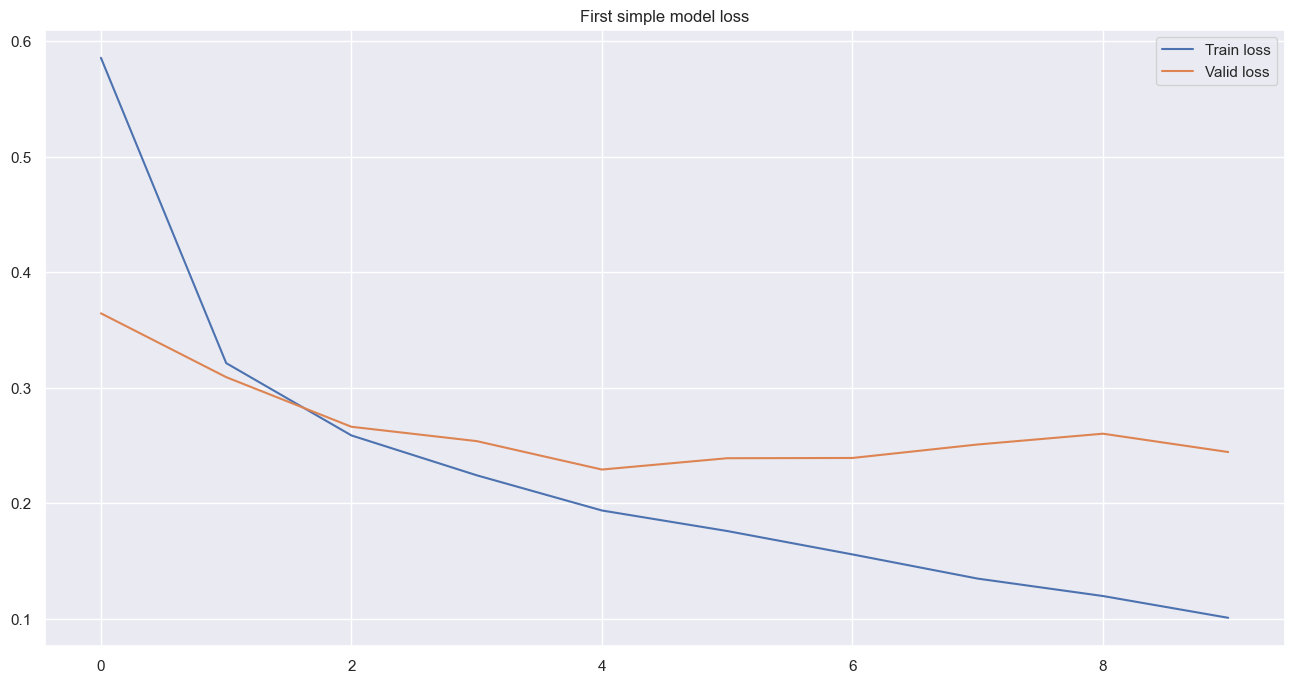

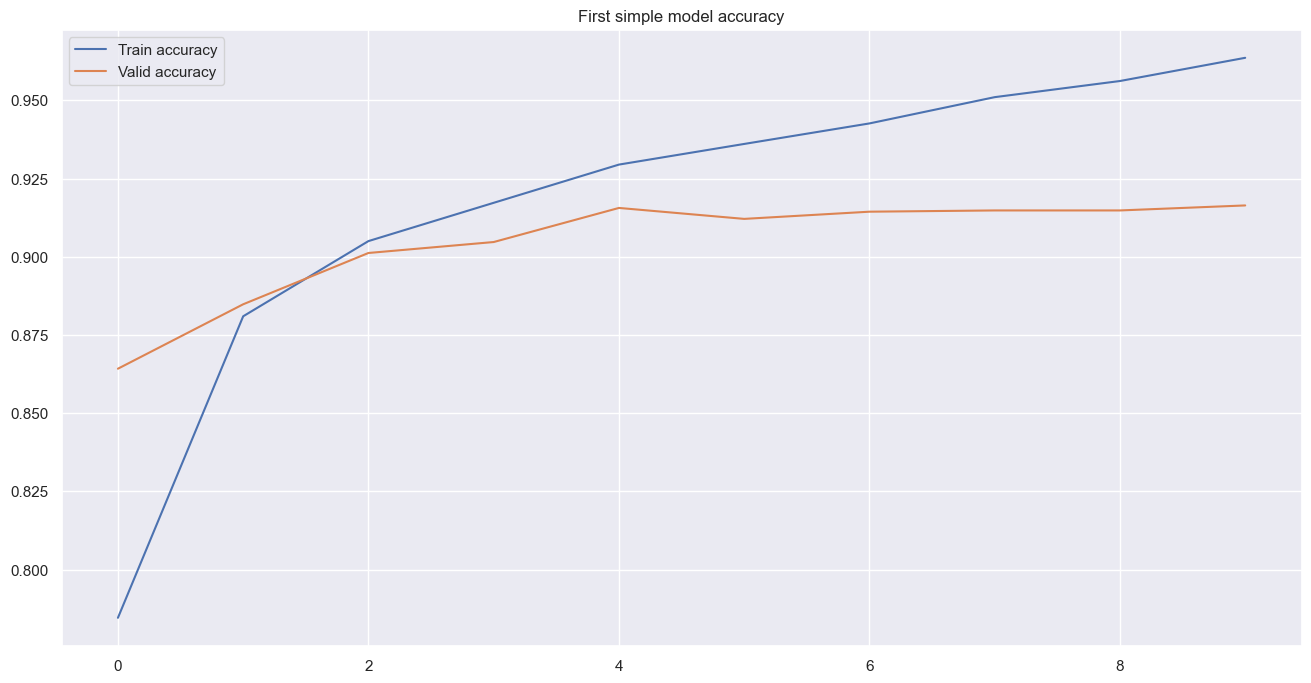

In [ ]:
fit(model2, train_loader, valid_loader, optimizer, loss, device, 10, 'First simple model')

In [ ]:
summary(model2, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
SecondModel                              [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Conv2d: 2-1                       [1, 16, 28, 28]           160
│    └─ReLU: 2-2                         [1, 16, 28, 28]           --
│    └─Conv2d: 2-3                       [1, 32, 28, 28]           4,640
│    └─ReLU: 2-4                         [1, 32, 28, 28]           --
│    └─MaxPool2d: 2-5                    [1, 32, 14, 14]           --
│    └─Conv2d: 2-6                       [1, 64, 14, 14]           18,496
│    └─ReLU: 2-7                         [1, 64, 14, 14]           --
│    └─MaxPool2d: 2-8                    [1, 64, 7, 7]             --
│    └─Conv2d: 2-9                       [1, 128, 7, 7]            73,856
│    └─ReLU: 2-10                        [1, 128, 7, 7]            --
│    └─MaxPool2d: 2-11                   [1, 128, 3, 3]            --
│  

In [ ]:
590 тыс параметров из 754 тыс приходятся на линейный слой после flatten, общее количество параметров считается избыточным, но в предудущих версиях
модели(тоже сверточной, ее нет в этом ноутбуке) параметров было больше, и результат для accuracy получал на 1-1.5% выше.

In [16]:
normalize = T.Normalize(mean=mean, std=std)
transform_train = T.Compose([
    T.RandomHorizontalFlip(0.3),
    T.RandomApply([T.RandomRotation(10)], p=0.3),
    T.ToTensor(),
    normalize
])
train_ds = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform_train)
train_set, val_set = random_split(train_ds, [train_size, val_size], generator=torch.Generator())

train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
valid_loader = DataLoader(val_set, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

In [ ]:
#optimizer = Adam(model2.parameters(), lr=3e-4)
model2 = SecondModel().to(device)
optimizer = torch.optim.SGD(model2.parameters(), lr=0.01, momentum=0.9)

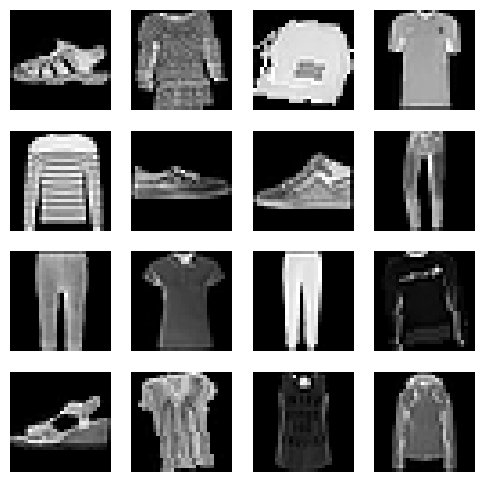

In [ ]:
images, labels = next(iter(train_loader))
fig, ax = plt.subplots(4, 4, figsize=(6,6))
for i in range(16):
    ax[i//4, i%4].imshow(images[i].squeeze(), cmap='gray')
    ax[i//4, i%4].axis('off')
plt.show()

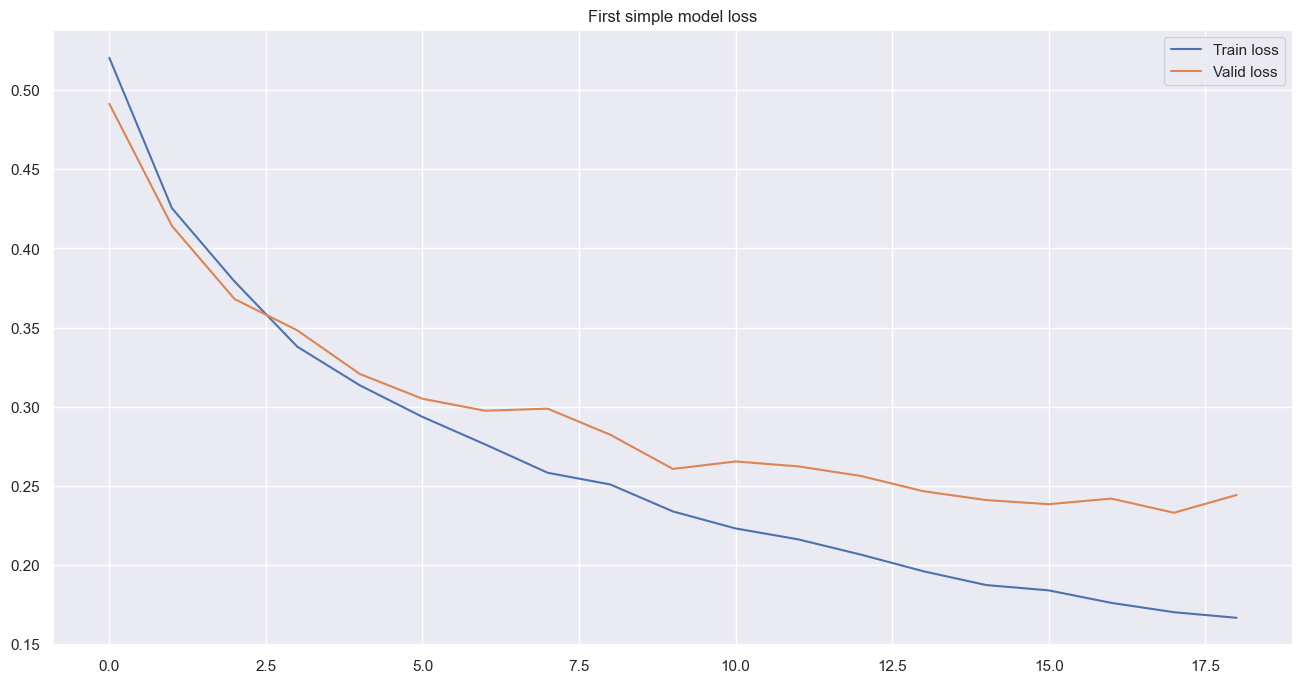

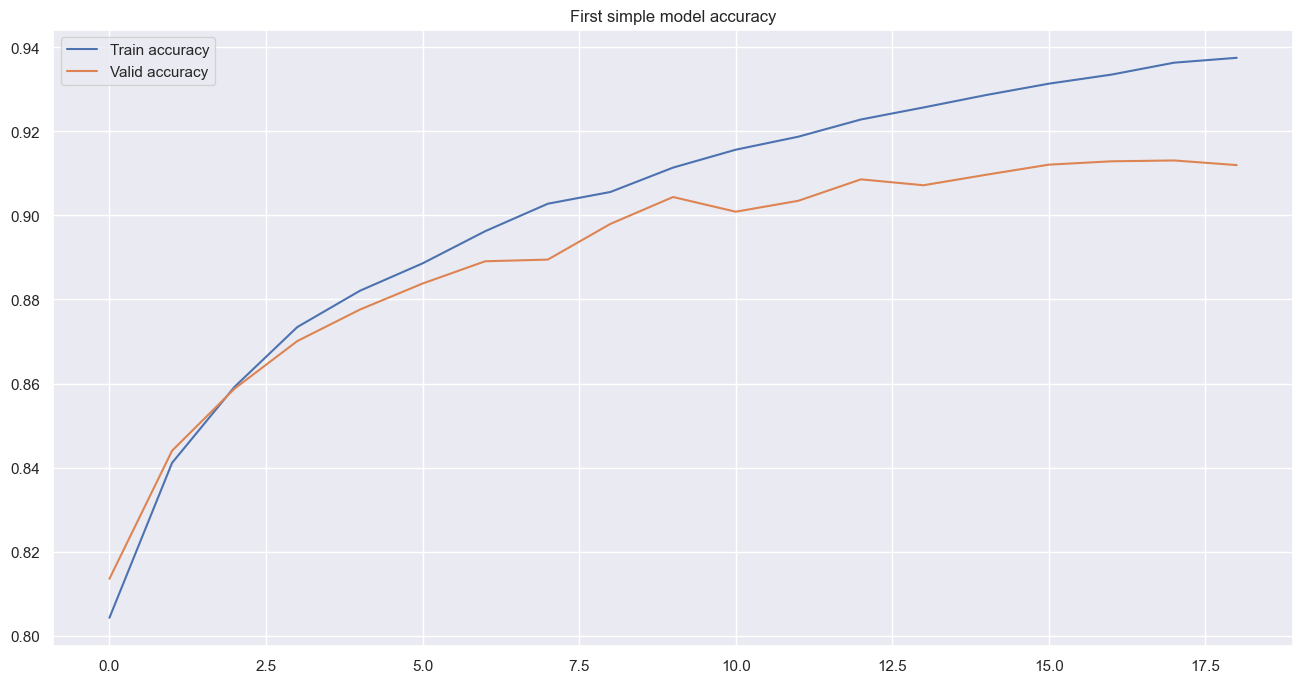

  4%|███▌                                                                             | 17/391 [00:18<06:37,  1.06s/it]


KeyboardInterrupt: 

In [ ]:
fit(model2, train_loader, valid_loader, optimizer, loss, device, 25, 'Second model')

In [ ]:
model2 = SecondModel().to(device)
optimizer = Adam(model2.parameters(), lr=3e-4)

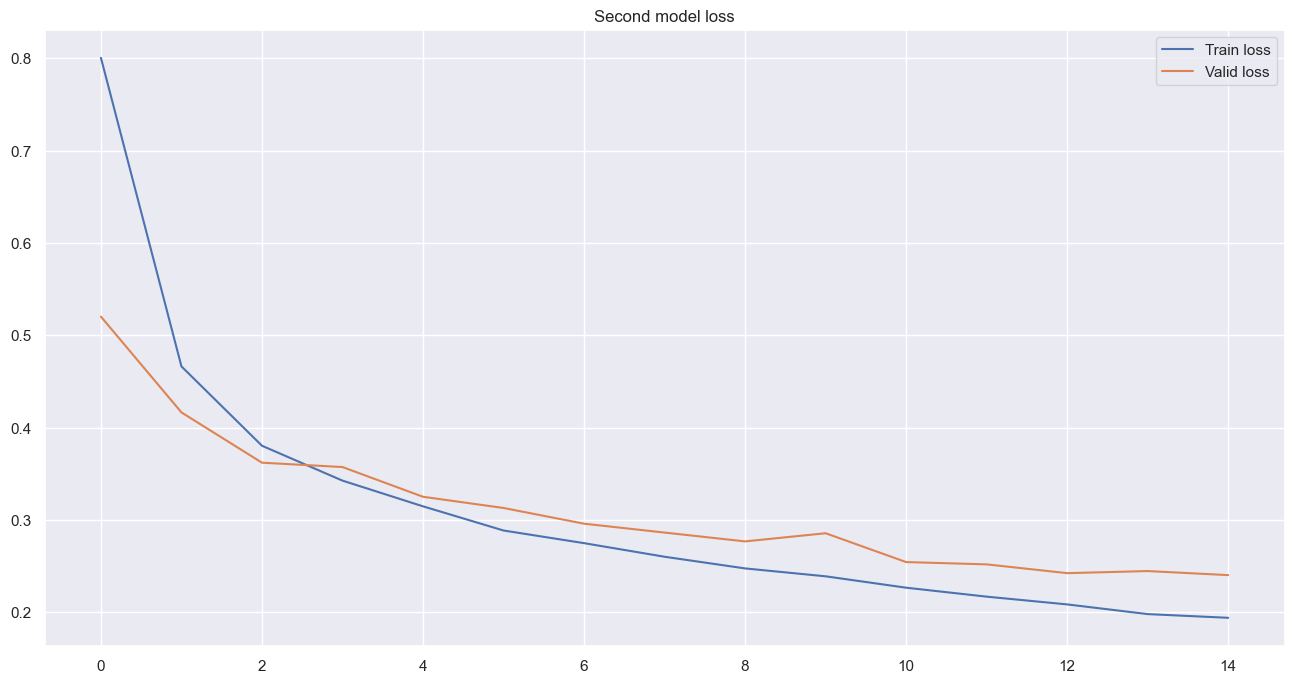

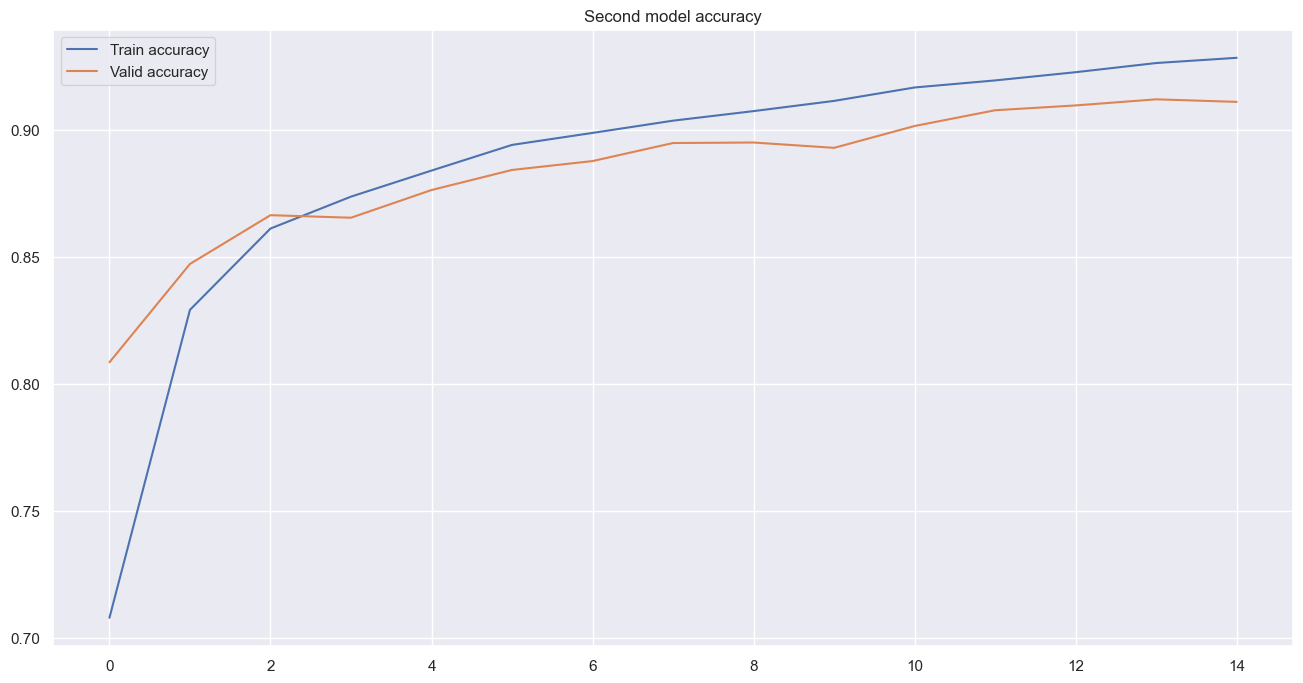

  0%|                                                                                          | 0/391 [00:11<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
fit(model2, train_loader, valid_loader, optimizer, loss, device, 25, 'Second model')

In [25]:
from torchinfo import summary
summary(model2, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
SecondModel                              [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Conv2d: 2-1                       [1, 16, 28, 28]           160
│    └─ReLU: 2-2                         [1, 16, 28, 28]           --
│    └─Conv2d: 2-3                       [1, 32, 28, 28]           4,640
│    └─ReLU: 2-4                         [1, 32, 28, 28]           --
│    └─MaxPool2d: 2-5                    [1, 32, 14, 14]           --
│    └─Conv2d: 2-6                       [1, 64, 14, 14]           18,496
│    └─ReLU: 2-7                         [1, 64, 14, 14]           --
│    └─MaxPool2d: 2-8                    [1, 64, 7, 7]             --
│    └─Conv2d: 2-9                       [1, 128, 7, 7]            73,856
│    └─ReLU: 2-10                        [1, 128, 7, 7]            --
│    └─MaxPool2d: 2-11                   [1, 128, 3, 3]            --
│  

не получилось настроить, чтобы аугментация давала положительный результат. снижал вероятность изменений, упрощал возможные изменения, поменял оптимизатор. sgd начал переобучаться примерно после 11 эпохи, адам примерно после 13, результат не превысил по метрике accuracy 91% , что хуже чем до внедрения аугментации. Возможно модель недостаточно сложная или learning rate слишком высок, но его уменьшение не дало значительной положительной динамики.

Добавьте skip-connection. Выведите summary модели, посмотрите на графики обучения, сделайте выводы.

In [17]:
class ResidualBlock(nn.Module):
    """Простой skip-connection: x -> Conv -> ReLU -> Conv + x"""
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
        )

    def forward(self, x):
        out = self.conv(x)
        return torch.relu(out + x)   # <-- skip connection


# --- Main model ---
class ThirdModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # 16×28×28
            nn.ReLU(),
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # 32×28×28
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 32×14×14
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 64×14×14
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 64×7×7
        )

        # --- Skip-connection block at 7×7 ---
        self.res_block = ResidualBlock(64)                # 64×7×7 → 64×7×7

        self.conv4 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 128×7×7
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 128×3×3
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        # --- Skip connection ---
        x = self.res_block(x)

        x = self.conv4(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x


In [18]:
model3 = ThirdModel().to(device)
optimizer = Adam(model3.parameters(), lr=1e-3)

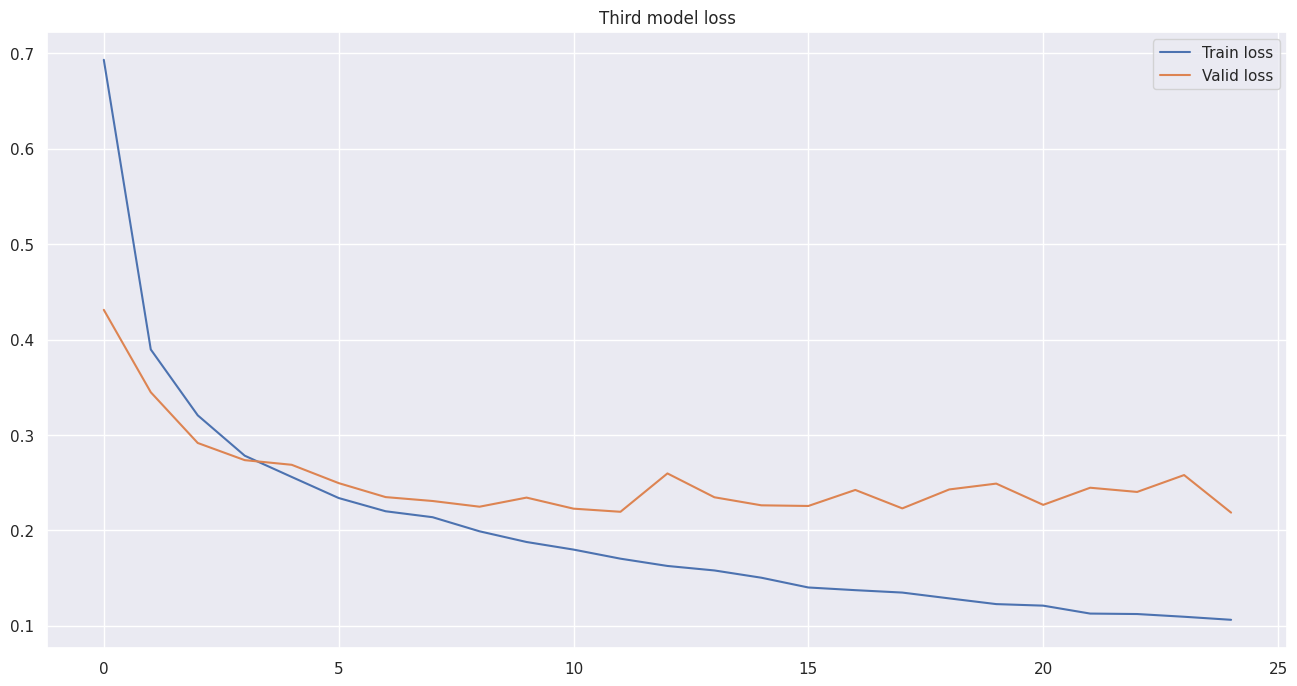

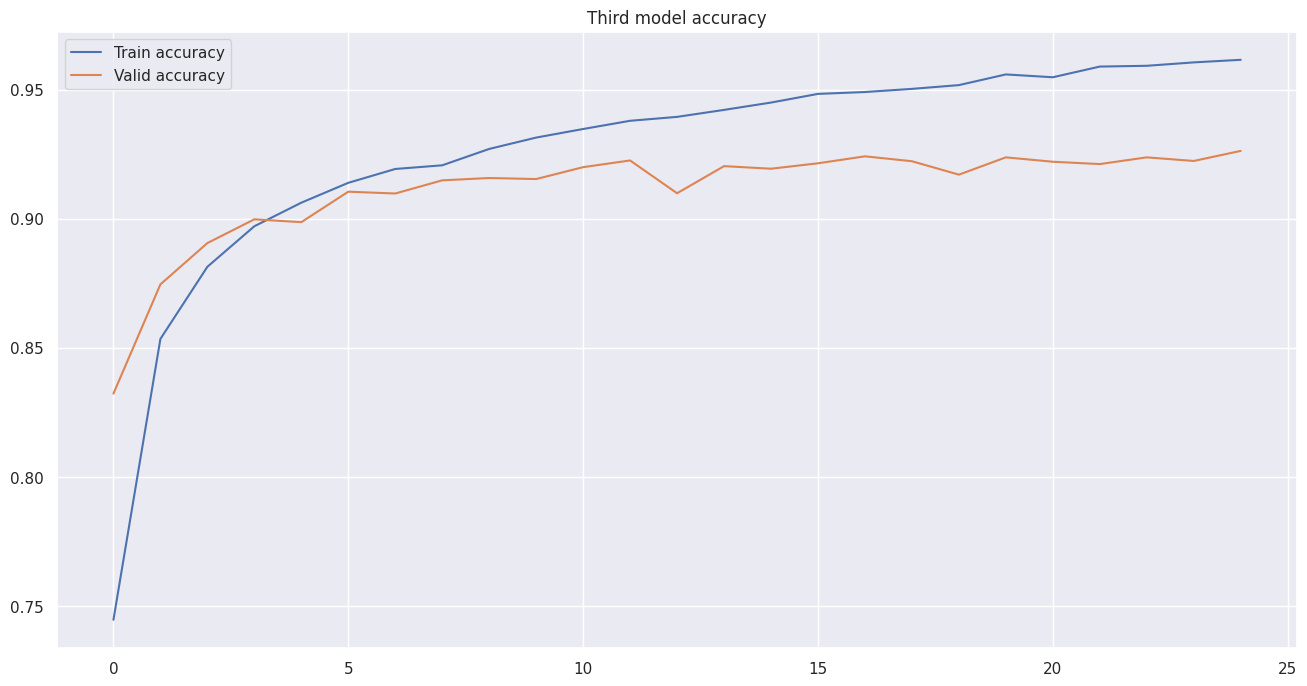

In [19]:
fit(model3, train_loader, valid_loader, optimizer, loss, device, 25, 'Third model')

In [26]:
summary(model3, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
ThirdModel                               [1, 10]                   --
├─Sequential: 1-1                        [1, 16, 28, 28]           --
│    └─Conv2d: 2-1                       [1, 16, 28, 28]           160
│    └─ReLU: 2-2                         [1, 16, 28, 28]           --
├─Sequential: 1-2                        [1, 32, 14, 14]           --
│    └─Conv2d: 2-3                       [1, 32, 28, 28]           4,640
│    └─ReLU: 2-4                         [1, 32, 28, 28]           --
│    └─MaxPool2d: 2-5                    [1, 32, 14, 14]           --
├─Sequential: 1-3                        [1, 64, 7, 7]             --
│    └─Conv2d: 2-6                       [1, 64, 14, 14]           18,496
│    └─ReLU: 2-7                         [1, 64, 14, 14]           --
│    └─MaxPool2d: 2-8                    [1, 64, 7, 7]             --
├─ResidualBlock: 1-4                     [1, 64, 7, 7]             --
│    └─

После экспериментов с параметрами модели и добавлением skip-connection получил результат примерно 92% метрики точности, что не является оптимальным для датасета mnist fashion. Модель начала переобучаться также после ~11 эпохи.

Очень рассчитываю получить рекомендации по оптимизации модели, несмотря на то что это очень большая тема, хотя бы конкретно для этого задания, моего случая.